# Analyze sales data to identify trends, profitable segments, and business improvement opportunities

# Import libaries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
df=pd.read_csv(r"C:\Users\nagar\Downloads\train.csv\train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

# Data Cleaning

In [9]:
#Convert Dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [15]:
print(df[['Order Date', 'Ship Date']].head())
print(df.dtypes)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [10]:
#Handle Missing Values
df['Postal Code'].fillna(0, inplace=True)

C:\Users\nagar\AppData\Local\Temp\ipykernel_32056\1688158443.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(0, inplace=True)


In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [22]:
print(df.duplicated().sum())

0


In [12]:
df['Sales'].value_counts()

Sales
12.960      55
19.440      39
15.552      39
10.368      35
25.920      34
            ..
2.496        1
10.984       1
364.080      1
268.576      1
4404.900     1
Name: count, Length: 5757, dtype: int64

In [13]:
df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [14]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

# Create New Columns 

In [16]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

print(df[['Order Date', 'Year', 'Month']].head())

  Order Date  Year  Month
0 2017-11-08  2017     11
1 2017-11-08  2017     11
2 2017-06-12  2017      6
3 2016-10-11  2016     10
4 2016-10-11  2016     10


We converted the order dates into a proper datetime format and extracted year and month features to analyze sales trends over time.”

# Monthly Sales Analysis

In [17]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


November (11) → 350,161  (highest)
December (12) → 321,480
September (9) → 300,103
These are your peak sales months


February (2) → 59,371 (lowest)
January (1) → 94,291

These are slow months

# Category Analysis

In [18]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


Technology → 827,455 ✅ (highest)

Furniture → 728,658

Office Supplies → 705,422

Technology is the highest revenue-generating category, indicating strong demand for tech products.

# sub_category_sales

In [19]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print(sub_category_sales.head(10))

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64


Top Sub-Categories by Sales:
Phones → 327,782 higest

Chairs → 322,822

Storage → 219,343

Tables → 202,810

Binders → 200,028

Phones are the top-selling sub-category, making them the biggest contributor to revenue.
    
Chairs also show strong performance, indicating consistent demand in furniture product


# Top Customers by Sales

In [20]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


Top Customers by Sales:
Sean Miller → 25,043 

Tamara Chand → 19,052

Raymond Buch → 15,117

Tom Ashbrook → 14,595

Adrian Barton → 14,473

We identified top customers who contribute the highest revenue to the business.
    
A small group of customers generates a significant portion of total sales.

In [21]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


Sales by Region:
West → 710,219  (highest)

East → 669,518

Central → 492,646

South → 389,151  (lowest)

The West region generates the highest sales, followed by the East, indicating strong performance in these areas.
 while South is lowest.

# Delivery Time Analysis

In [24]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['Delivery Days'].describe())

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Days, dtype: float64


Delivery time affects customer experience.

# Sales by Category (Comparison Chart)

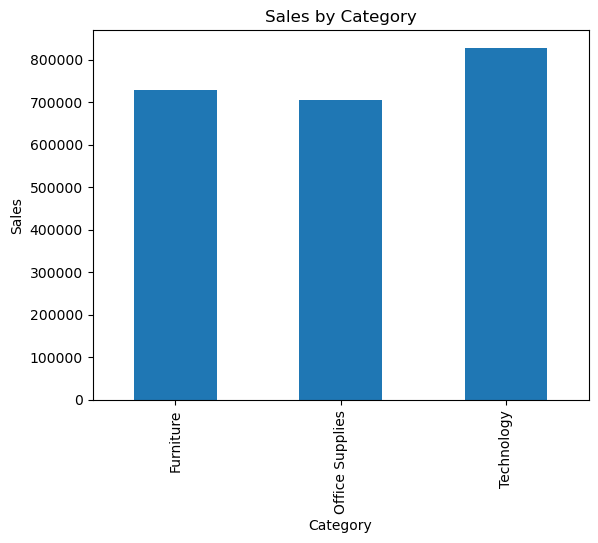

In [25]:
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Sales Trend Over Time (Line Chart)

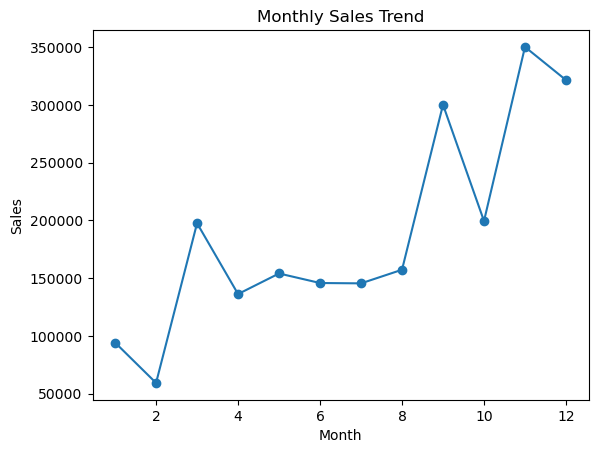

In [26]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

 Sales peak in November and December, showing seasonal demand.

# Sales Distribution (Histogram)

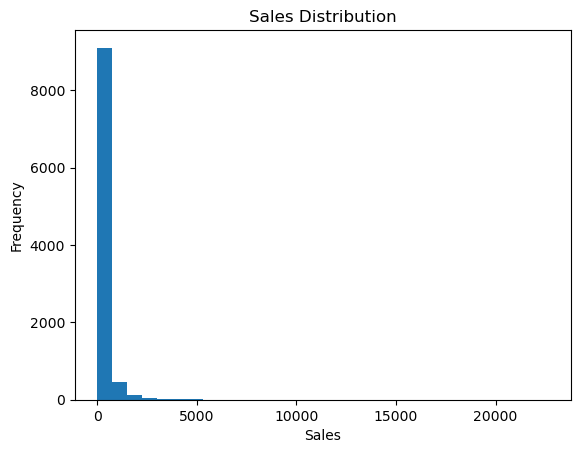

In [27]:
df['Sales'].plot(kind='hist', bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

# Category vs Region

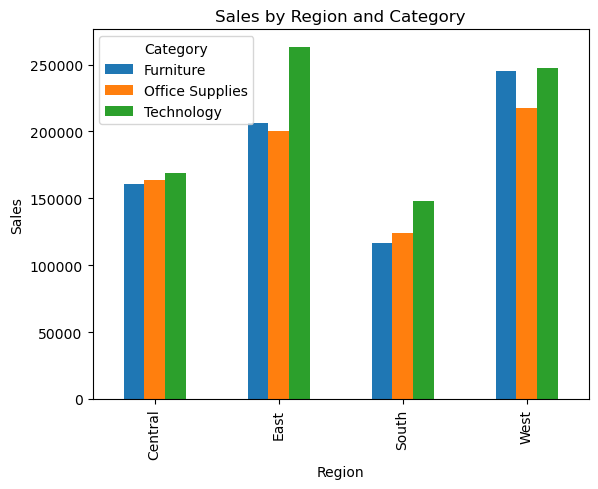

In [31]:
pivot = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

pivot.plot(kind='bar')
plt.title("Sales by Region and Category")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

Technology category generates the highest revenue.

# Sub-Category vs Sales

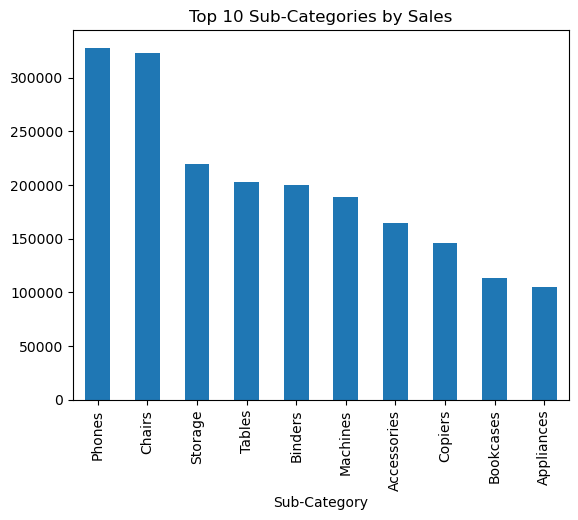

In [32]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_sub.plot(kind='bar')
plt.title("Top 10 Sub-Categories by Sales")
plt.show()

Phones and Chairs are top-performing products.

# Delivery Time vs Sales

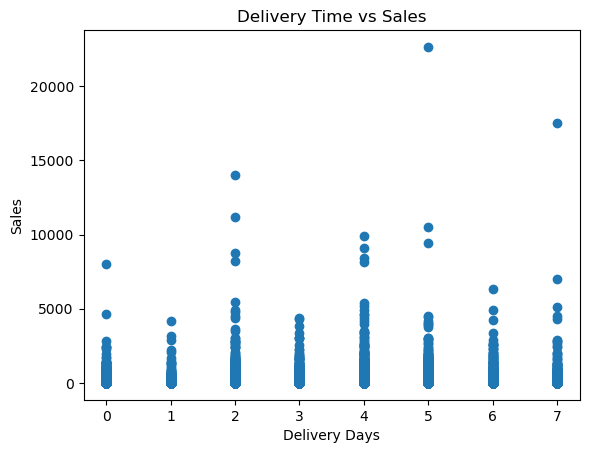

In [33]:
plt.scatter(df['Delivery Days'], df['Sales'])
plt.title("Delivery Time vs Sales")
plt.xlabel("Delivery Days")
plt.ylabel("Sales")
plt.show()

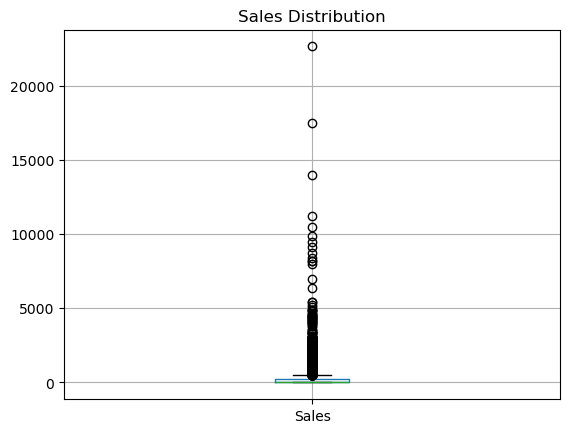

In [35]:
df.boxplot(column='Sales')
plt.title("Sales Distribution")
plt.show()

# Customer Type Analysis

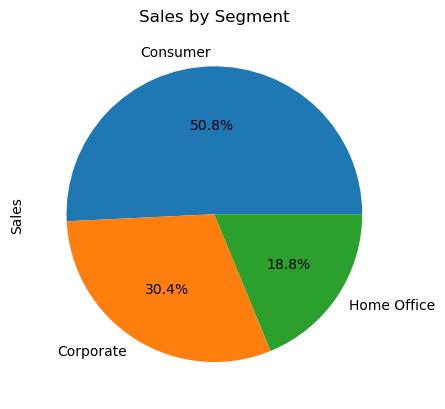

In [36]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Segment")
plt.show()

 consumer contribute a large portion of total sales.

Conclusion

- Sales are seasonal
- Technology is top category
- Few customers generate high revenue
- Some regions need improvement